In [1]:
%load_ext aiida
%aiida

Loaded AiiDA DB environment - profile name: 2.0-dev.

In [2]:
import numpy as np
from aiida import engine, orm
from aiida.orm import StructureData
from ase.build import bulk
from aiida_abacus.workflows.band import AbacusBandWorkChain

###
# set up code
computer = orm.load_computer("localhost")


In [3]:
builder = AbacusBandWorkChain.get_builder()
code = orm.load_code("abacus-3.10@localhost")
builder.base.abacus.code = code
builder.base.abacus.metadata.options = {
    "resources": {
        "num_machines": 1,
        "num_mpiprocs_per_machine": 1,  # use 1 cores per machine
    },
    "max_wallclock_seconds": 180,  # how long it can run before it should be killed
    # 'withmpi': False, # Set withmpi to False in case abacus was compiled without MPI support.
}

builder.structure = StructureData(ase=bulk("Si", "diamond", 5.43))
builder.base.kpoints_distance = orm.Float(0.3)
builder.base.pseudo_family = "SG15_V1.0/dzp"

/home/bonan/miniconda3/envs/aiida-2.4-dev/lib/python3.12/site-packages/plumpy/ports.py:200: UserWarning: the validator `check_pseudo_family` has a signature that only takes a single argument.
    This has been deprecated and the new signature is `validator(value, port)` where the `port` argument will be the
    port instance to which the validator has been assigned.
  warnings.warn(VALIDATOR_SIGNATURE_DEPRECATION_WARNING.format(self.validator.__name__))


In [4]:
builder.base.abacus.parameters = {
    "input": {  # pseudo_dir will be set by the plugin based on the pseudos
        # 'symmetry': 1,
        "basis_type": "lcao",
        # "ecutwfc": 100,
        "scf_thr": 1e-4,  # 1e-7,
        # 'scf_nmax': 100,
        "device": "cpu",
        # 'ks_solver': 'dav_subspace',
        # 'precision': 'double',
    }
}
builder.band_settings = {"symprec": 0.1}

In [5]:
engine.run_get_node(builder)

05/24/2025 04:39:16 PM <473273> aiida.broker.rabbitmq: [WARNING] RabbitMQ v3.12.1 is not supported and will cause unexpected problems!
05/24/2025 04:39:16 PM <473273> aiida.broker.rabbitmq: [WARNING] It can cause long-running workflows to crash and jobs to be submitted multiple times.
05/24/2025 04:39:16 PM <473273> aiida.broker.rabbitmq: [WARNING] See https://github.com/aiidateam/aiida-core/wiki/RabbitMQ-version-to-use for details.
/home/bonan/miniconda3/envs/aiida-2.4-dev/lib/python3.12/site-packages/plumpy/ports.py:200: UserWarning: the validator `check_pseudo_family` has a signature that only takes a single argument.
    This has been deprecated and the new signature is `validator(value, port)` where the `port` argument will be the
    port instance to which the validator has been assigned.
  warnings.warn(VALIDATOR_SIGNATURE_DEPRECATION_WARNING.format(self.validator.__name__))
/home/bonan/miniconda3/envs/aiida-2.4-dev/lib/python3.12/site-packages/spglib/spglib.py:115: DeprecationW

ResultAndNode(result={'primitive_structure': <StructureData: uuid: d42493c1-5f21-4d25-bec5-7aeb48a424db (pk: 6564)>, 'seekpath_parameters': <Dict: uuid: d8c32f0a-d364-40a9-b8f2-ea40b84ab41f (pk: 6562)>, 'band_structure': <BandsData: uuid: a01350c8-1b72-4c35-9eff-f5504576acad (pk: 6587)>}, node=<WorkChainNode: uuid: a1e1c4d0-61eb-4883-88cb-ecd46acd77c4 (pk: 6559) (aiida_abacus.workflows.band.AbacusBandWorkChain)>)

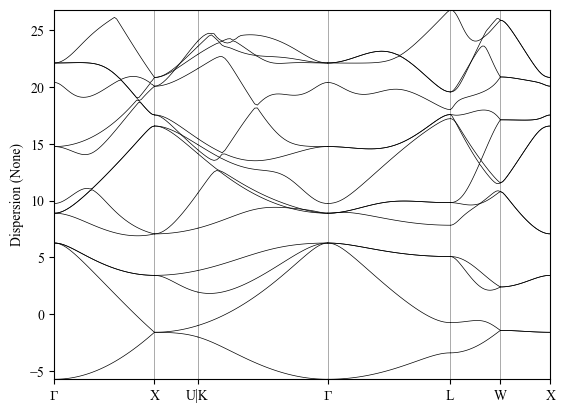

In [8]:
orm.load_node("a01350c8-1b72-4c35-9eff-f5504576acad").show_mpl()


In [7]:
orm.load_node("80c42577-94c5-4f8f-b487-359ebcdbc23f").base.extras.all


{'_aiida_hash': 'f8d8ab7b922d711585edf86cee2142426a7c7ddeddb7e4805e9083d3f67e058e'}